# Chapter 11 - Advanced Topics and Cutting-Edge Research


In [1]:
# Here some installs that we will be using in multiple parts of the chapter

!pip install smolagents ddgs
!pip install -U transformers==5.2.0
!pip install huggingface_hub



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 61.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 56.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
   

In [ ]:
# Very important to be logged in!
from huggingface_hub import login
login()


In [2]:
from smolagents import Tool, CodeAgent, InferenceClientModel, DuckDuckGoSearchTool
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
from pydantic import BaseModel, Field
from typing import Any
from typing import TypeAlias

import torch
import requests
from PIL import Image


## 11.1 Agentic Vision Language Models
### 11.1.2 Introduction to Smolagents

First toy example

In [ ]:
class AdditionTool(Tool):
    name = "addition_tool"
    description = "Adds two numbers together"
    inputs = {
        "first_number": {
            "type": "integer",
            "description": "first number to add"
        },
        "second_number": {
            "type": "integer",
            "description": "second number to add"
        }
    }
    output_type = "integer"

    def forward(self, first_number, second_number):
        return first_number + second_number

model = InferenceClientModel()
agent = CodeAgent(tools=[AdditionTool()], model=model)
result = agent.run("What is 41 plus 1?")

# Let's inspect what happened inside the loop

for step in agent.memory.steps:
    print(f"{type(step).__name__}: {step}")


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What is 41 plus 1?                                                                                              │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = 5 + 3 + 1294.678                                                                                        
  final_answer(result)                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 1302.678

[Step 1: Duration 1.63 seconds| Input tokens: 2,081 | Output tokens: 294]

TaskStep: TaskStep(task='What is 41 plus 1?', task_images=None)
ActionStep: ActionStep(step_number=1, timing=Timing(start_time=1772698328.57462, end_time=1772698330.2066424, duration=1.6320223808288574), model_input_messages=[ChatMessage(role=<MessageRole.SYSTEM: 'system'>, content=[{'type': 'text', 'text': 'You are an expert assistant who can solve any task using code blobs. You will be given a task to solve as best you can.\nTo do so, you have been given access to a list of tools: these tools are basically Python functions which you can call with code.\nTo solve the task, you must plan forward to proceed in a series of steps, in a cycle of Thought, Code, and Observation sequences.\n\nAt each step, in the \'Thought:\' sequence, you should first explain your reasoning towards solving the task and the tools that you want to use.\nThen in the Code sequence you should write the code in simple Python. The code sequence must be opened with \'<code>\', and closed with \'</code>\'.\nDuring ea

### Leveraging Hugging Face Spaces as tools

Loaded as API: https://black-forest-labs-flux-1-dev.hf.space ✔


/usr/local/lib/python3.12/dist-packages/smolagents/tools.py:666: UserWarning: Since `api_name` was not defined, it was automatically set to the first available API: `/infer`.
  warnings.warn(


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a futuristic city with flying cars at sunset                                               │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  image = image_generator(                                                                                         
      prompt="A futuristic cityscape at sunset with flying cars zooming through the sky, glowing neon lights on    
  skyscrapers, reflections on wet streets, highly detailed digital art, cinematic lighting",                       
      seed=42,                                                                                                     
      randomize_seed=True,                                                                                         
      width=1024,                                                                                                  
      height=768,                                                                                                  
      guidance_scale=7.5,                                                                                          
      num_inference_steps=50                                                                                       
  )                                                                                                                
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  image = image_generator(                                                                                         
      prompt="A futuristic cityscape at sunset with flying cars zooming through the sky, glowing neon lights on    
  skyscrapers, reflections on wet streets, highly detailed digital art, cinematic lighting",                       
      seed=42,                                                                                                     
      randomize_seed=True,                                                                                         
      width=768,                                                                                                   
      height=512,                                                                                                  
      guidance_scale=7.5,                                                                                          
      num_inference_steps=25                                                                                       
  )                                                                                                                
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: /tmp/gradio/eab4ca9c4825c5aa5d067772308034b15f78d1d89ab79dd391c7712caf255eca/image.webp

[Step 2: Duration 17.37 seconds| Input tokens: 4,625 | Output tokens: 2,740]

ValueError: Cannot embed the 'webp' image format

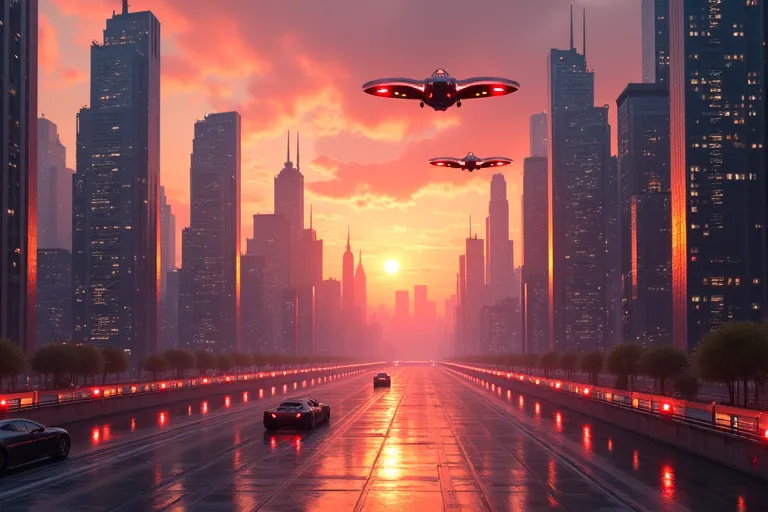

In [ ]:
image_gen_tool = Tool.from_space(
    space_id="black-forest-labs/FLUX.1-dev",
    name="image_generator",
    description="Generates an image following your prompt. Returns the image.")

agent = CodeAgent(tools=[image_gen_tool], model=model)

agent.run("Generate an image of a futuristic city with flying cars at sunset")


### Connecting your model

In [ ]:
model = InferenceClientModel()
agent = CodeAgent(
	tools=[DuckDuckGoSearchTool()],
	model=model
	)
result = agent.run("What is the current weather in Paris?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What is the current weather in Paris?                                                                           │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = web_search(query="current weather in Paris")                                                            
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Search Results

[Paris, Ville deParis, FranceWeatherForecast | 
AccuWeather](https://www.accuweather.com/en/fr/paris/623/weather-forecast/623)
CurrentWeather.ParisWeatherRadar. Static Radar Temporarily Unavailable. Thank you for your patience as we work to 
get everything up and running again.

[ParisFranceWeather| ten dayweatherforecast | Euronews](https://www.euronews.com/weather/europe/france/paris)
WeatherForecast forParis| euronews, previsions forParis, France (temperature, wind, rainfall…).

[14-dayweatherforecast forParis. - BBCWeather](https://www.bbc.com/weather/6942553)
Search for a location.Paris-Weatherwarnings issued. 14-day forecast.

[Paris, Ile-de-FranceWeather- Hourly Forecasts and Local... - AOL](https://www.aol.com/weather/forecast/fr/paris/)
Get theParis, Ile-de-France localweatherforecast by the hour and the next 10 days.

[Yr -Weatherforecast forParisfor the next 10 
days.](https://www.yr.no/en/forecast/daily-table/2-2988507/France/Île-de-France+Region/Paris+Department/Paris)
Capital,ParisDepartment, Île-de-France Region (France), elevation 35 m.Currentconditions.

[Weather-Paris- 14-Day Forecast & Rain | Ventusky](https://www.ventusky.com/paris)
Paris-Weatherforecast for 14 days, information from meteorological stations, webcams, sunrise and sunset, wind and 
precipitation maps for this place.

[Parishava durumu 30 günlükParis1 aylık hava durumu » 
Meteoroloji...](https://www.meteoprog.com/tr/weather/Paris/month/)
Parisaylık hava durumu ⊳Paris, Franca > Kesin Hava sıcaklığı 30 günlük ⋄ Yağış ⋄ Rüzgar gücü ⋄ Nem ⋄ Atmosferik 
basınç ve diğerleri şimdilik - METEOPROG.22 Mart. +14°+5°. *weatherforecast is calculated based on historical data.

[WeatherAtlas | GlobalWeatherforecast and Climate information](https://www.weather-atlas.com/)
Weatherforecast and climate data for all countries.Currenttemperature andweatherconditions.

[ParisweatherinMarch 2026 |Paris14 
dayweather](https://www.weather25.com/europe/france/ile-de-france/paris?page=month&month=March)
Fullweatherforecast forParisin March 2026. Check the temperatures, chance of rain and moreinParisduring March.

[TheWeatherYear Round Anywhere on Earth -WeatherSpark](https://weatherspark.com/)
Get monthly, daily, and hourly graphical reports of the averageweather: daily highs and lows, rain, clouds, wind, 
etc.

Out: None

[Step 1: Duration 4.14 seconds| Input tokens: 2,085 | Output tokens: 584]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 7 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("10°C")                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 10°C

[Step 7: Duration 9.19 seconds| Input tokens: 34,284 | Output tokens: 6,982]

10°C


# 11.1.3 Computer Use Agents
## Using Holo2-Localization

In [ ]:

model = AutoModelForImageTextToText.from_pretrained(
     "Hcompany/Holo2-4B" ,
    dtype=torch.bfloat16,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained("Hcompany/Holo2-4B")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/714 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

In [ ]:

image_url = "https://huggingface.co/datasets/vlmbook/images/resolve/main/calendar.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)
image_processor_config = processor.image_processor
resized_height, resized_width = smart_resize(
    image.height,
    image.width,
    factor=image_processor_config.patch_size * image_processor_config.merge_size,
    min_pixels=image_processor_config.size.get("shortest_edge", None),
    max_pixels=image_processor_config.size.get("longest_edge", None),
)
processed_image = image.resize(size=(resized_width, resized_height), resample=Image.Resampling.LANCZOS)


In [ ]:
class ClickCoordinates(BaseModel):
    x: int = Field(ge=0, le=1000, description="The x coordinate, normalized between 0 and 1000.")
    y: int = Field(ge=0, le=1000, description="The y coordinate, normalized between 0 and 1000.")
ChatMessage: TypeAlias = dict[str, Any]
task = "Book a hotel in Paris on August 3rd for 3 nights"
prompt = f"""Localize an element on the GUI image according to the provided target and output a click position.
  * You must output a valid JSON following the format: {ClickCoordinates.model_json_schema()}
  Your target is:"""
messages = [
    {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"{prompt}\n{task}"},
            ],
    },
]


In [ ]:
text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, thinking=False)
inputs = processor(
    text=[text_prompt],
    images=[processed_image],
    padding=True,
    return_tensors="pt",
).to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=32)
decoded_output = processor.decode(generated_ids, skip_special_tokens=True)
print(decoded_output)


['user\nLocalize an element on the GUI image according to the provided target and output a click position.\n  * You must output a valid JSON following the format: {\'properties\': {\'x\': {\'description\': \'The x coordinate, normalized between 0 and 1000.\', \'maximum\': 1000, \'minimum\': 0, \'title\': \'X\', \'type\': \'integer\'}, \'y\': {\'description\': \'The y coordinate, normalized between 0 and 1000.\', \'maximum\': 1000, \'minimum\': 0, \'title\': \'Y\', \'type\': \'integer\'}}, \'required\': [\'x\', \'y\'], \'title\': \'ClickCoordinates\', \'type\': \'object\'}\n  Your target is:\nBook a hotel in Paris on August 3rd for 3 nights\nassistant\n<think>\n\n</think>\n\n{"x":549,"y":386}']


In [ ]:
# Let’s take a look at the decoded content stripped of special tokens and the input.
input_len = len(inputs["input_ids"][0])
outs = processor.batch_decode(generated_ids[:, input_len:], skip_special_tokens=True)
print(outs)

['{"x":549,"y":386}']


In [ ]:
action = ClickCoordinates.model_validate_json(outs[0])
print("action:", action)

action: x=549 y=386


Predicted action: Click on 'Book a hotel in Paris on August 3rd for 3 nights' at coordinates (931.104, 333.504)


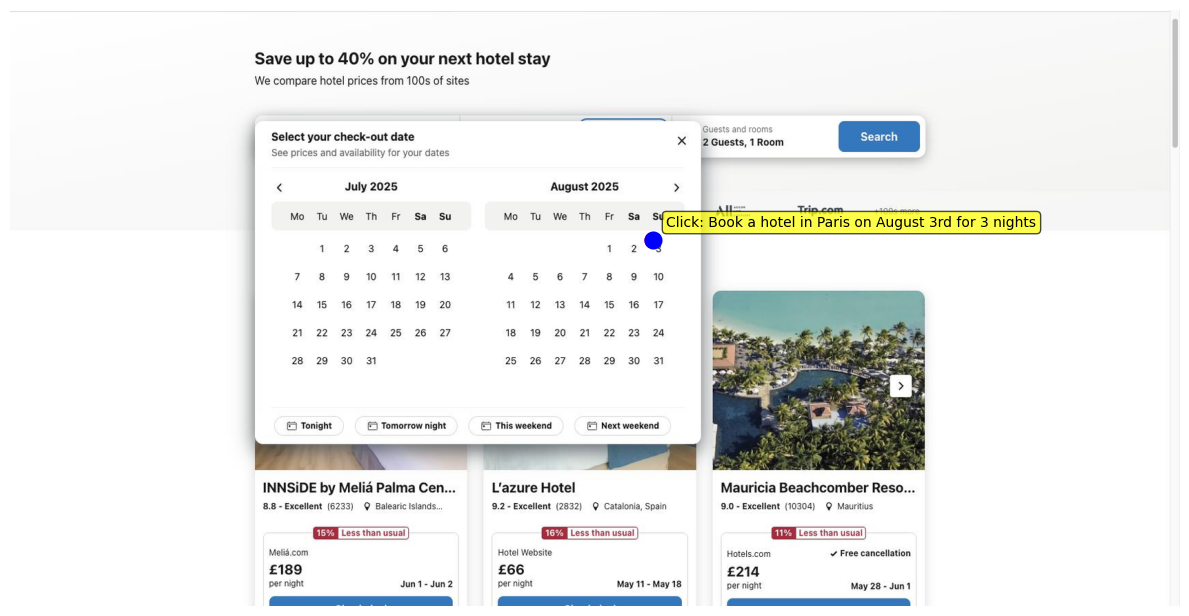

In [ ]:
# Visualizing the result:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.figure import Figure
from matplotlib.axes import Axes

def visualize_click(action, processed_img, task):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(processed_img)
    x = action.x / 1000 * processed_img.width
    y = action.y / 1000 * processed_img.height
    print(f"Predicted action: Click on '{task}' at coordinates ({x}, {y})")

    ax.plot(x, y, "bo", markersize=10, markeredgewidth=3)

    circle = patches.Circle((x, y), 10, linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(circle)

    ax.annotate(
            f"Click: {task}",
            xy=(x, y),
            xytext=(x + 20, y - 20),
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
            fontsize=10,
        )
    ax.axis("off")
    plt.tight_layout()
    return fig, ax

fig, ax = visualize_click(action, processed_image, task=task)
plt.show()


### Using ScaleCUA for Agentic Computer Use


In [3]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "OpenGVLab/ScaleCUA-3B", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("OpenGVLab/ScaleCUA-3B", min_pixels=3136, max_pixels=2109744)


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

In [4]:
SYSTEM_PROMPT = '''You are an autonomous GUI agent capable of operating on desktops, mobile devices, and web browsers. Your primary function is to analyze screen captures and perform appropriate UI actions to complete assigned tasks.
## Action Space
def click(
x: float | None = None,
y: float | None = None,
clicks: int = 1,
button: str = "left",
) -> None:
"""Clicks on the screen at the specified coordinates. The `x` and `y` parameter specify where the mouse event occurs. If not provided, the current mouse position is used. The `clicks` parameter specifies how many times to click, and the `button` parameter specifies which mouse button to use ('left', 'right', or 'middle')."""
pass
def doubleClick(
x: float | None = None,
y: float | None = None,
button: str = "left",
) -> None:
"""Performs a double click. This is a wrapper function for click(x, y, 2, 'left')."""
pass
def rightClick(x: float | None = None, y: float | None = None) -> None:
"""Performs a right mouse button click. This is a wrapper function for click(x, y, 1, 'right')."""
pass
def moveTo(x: float, y: float) -> None:
"""Move the mouse to the specified coordinates."""
pass
def dragTo(
x: float | None = None, y: float | None = None, button: str = "left"
) -> None:
"""Performs a drag-to action with optional `x` and `y` coordinates and button."""
pass
def swipe(
from_coord: tuple[float, float] | None = None,
to_coord: tuple[float, float] | None = None,
direction: str = "up",
amount: float = 0.5,
) -> None:
"""Performs a swipe action on the screen. The `from_coord` and `to_coord` specify the starting and ending coordinates of the swipe. If `to_coord` is not provided, the `direction` and `amount` parameters are used to determine the swipe direction and distance. The `direction` can be 'up', 'down', 'left', or 'right', and the `amount` specifies how far to swipe relative to the screen size (0 to 1)."""
pass
def long_press(x: float, y: float, duration: int = 1) -> None:
"""Long press on the screen at the specified coordinates. The `duration` specifies how long to hold the press in seconds."""
pass
## Input Specification
- Screenshot of the current screen + task description
## Output Format
<action>
[A set of executable action command]
</action>
## Note
- Avoid action(s) that would lead to invalid states.
- The generated action(s) must exist within the defined action space.
- The generated action(s) should be enclosed within <action></action> tags.'''


In [5]:
messages = [
    {
      "role": "system",
      "content":[
        {
          "type": "text",
          "text": SYSTEM_PROMPT,
        }
      ]
    },
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://huggingface.co/datasets/vlmbook/images/resolve/main/calendar.jpg",
            },
            {"type": "text", "text": "Book a hotel from July 3rd to July 6th."},
        ],
    }
]


In [6]:
inputs = processor.apply_chat_template(
    messages, tokenize=True, return_dict=True, add_generation_prompt=True, return_tensors="pt"
)
inputs = inputs.to("cuda")
generated_ids = model.generate(**inputs, max_new_tokens=128)
input_len = len(inputs["input_ids"][0])
action_str = processor.batch_decode(generated_ids[:, input_len:], skip_special_tokens=True)
print(action_str)


['<action>\nclick(x=528, y=339)\nclick(x=635, y=339)\n</action>']


In [7]:
import re
def parse_clicks_from_action_block(action_text):
    action_text = "\n".join(action_text)
    pattern = r"click\s*\(\s*x\s*=\s*(\d+)\s*,\s*y\s*=\s*(\d+)\s*\)"
    matches = re.findall(pattern, action_text)
    clicks = [(int(x), int(y)) for x, y in matches]
    return clicks


[(528, 339), (635, 339)]


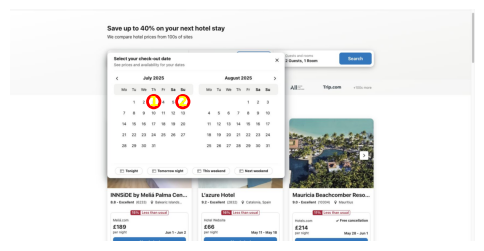

In [8]:
import matplotlib.pyplot as plt

def visualize_clicks_on_image(
    image,
    clicks,
):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    ax = plt.gca()
    if clicks:
        xs, ys = zip(*clicks)
        ax.scatter(xs, ys, s=80, edgecolors="red", facecolors="none", linewidths=2)
        for i, (x, y) in enumerate(clicks, start=1):
            ax.text(
                x,
                y,
                str(i),
                color="yellow",
                fontsize=10,
                ha="center",
                va="center",
                weight="bold",
            )
    ax.set_axis_off()
    plt.show()

clicks = parse_clicks_from_action_block(action_str)
print(clicks)
image_url = "https://huggingface.co/datasets/vlmbook/images/resolve/main/calendar.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)

visualize_clicks_on_image(
    image=image,
    clicks=clicks,
)
